# Metric (Distance-Based) Methods in Machine Learning


The essence of metric methods is well captured by the phrase:

> "Tell me who your friends are, and I’ll tell you who you are."

Algorithms of this class **do not have a training phase**. They simply store the entire training dataset, and during inference they look for objects similar to the target.  

This process is called **lazy learning** because no real training occurs.  

As a result, the algorithm becomes practically **unusable for large datasets**.

However, the algorithm is **simple and easily interpretable**. Nowadays, it is **rarely used** in practice.

https://education.yandex.ru/handbook/ml/article/metricheskiye-metody#metod-k-blizhajshih-sosedej-knn

https://scikit-learn.org/stable/modules/neighbors.html

### **KNN (k-Nearest Neighbors)**
- **Type:** Supervised (lazy)  
- **How it works:** Finds *k* nearest neighbors using a distance metric (Euclidean, Manhattan, Cosine etc.) and predicts via majority vote or average.  
- **Pros:** Simple, interpretable, good as a baseline, can be used for both classification and regression.
- **Cons:** Slow on large datasets, memory-inefficient, computationally expensive, sensitive to feature scaling (requires scaling), can overfit, struggles with many features
- **Use cases:** Small-scale classification/regression, recommendation baselines, anomaly detection  (Nowadays, it is **rarely used** in practice.)



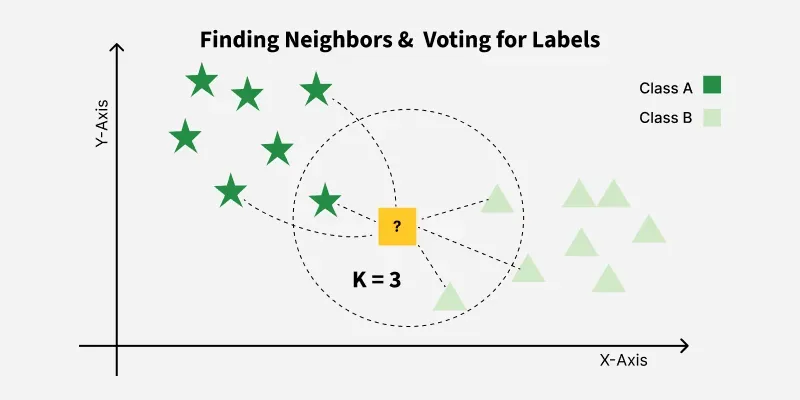

# Choosing a Distance Function

How to choose the distance function \( \rho \) correctly?  

In the vast majority of cases, the standard **Euclidean distance** is a good choice.  
However, in some situations, other distance functions may be more appropriate.


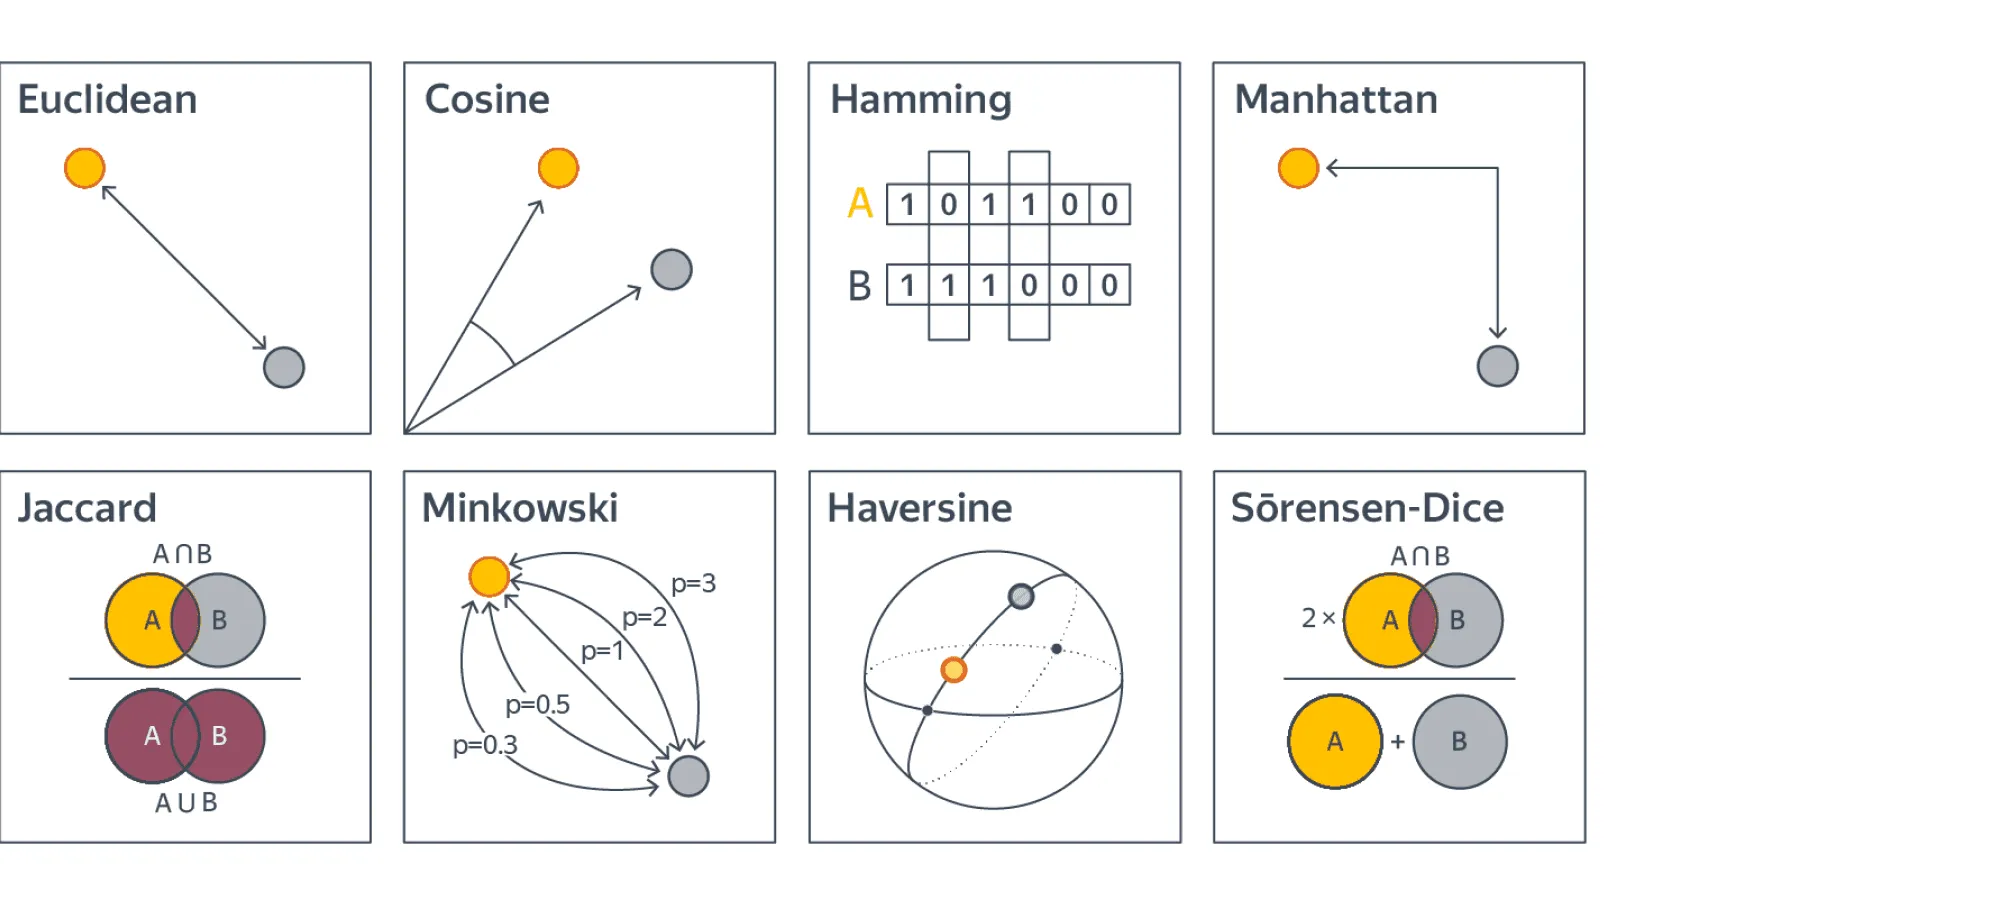

### 1.Euclidean Distance

The **Euclidean distance** (L2 distance) is the most commonly used distance metric in machine learning. It represents the "straight-line" distance between two points in n-dimensional space.


- **Most common metric** for distance-based algorithms like KNN, KMeans, and clustering.  
- Corresponds to the intuitive straight-line distance in geometry.  
- **Sensitive to outliers**: a large difference in a single feature can dominate the distance.  
- **Feature scaling is important**: if features have different scales, normalize them before computing distance.  

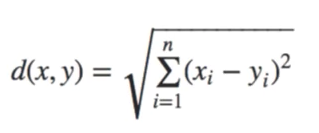

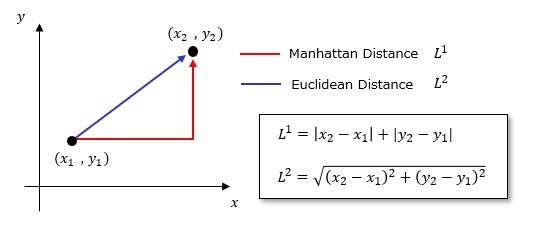

### 2.Manhattan Metric

The **Manhattan distance** (L1 distance) measures the distance between two points by summing the absolute differences of their coordinates. It is often more robust to outliers than Euclidean distance, especially in high-dimensional spaces.


- **Also called L1 distance**.  
- More **robust to outliers** than Euclidean distance: a large difference in a single feature does not dominate the total distance.  
- Often used in **high-dimensional spaces**.  
- Works well when the difference in each feature should contribute **linearly** to the distance.  
- Commonly used in KNN, clustering, and other distance-based algorithms.


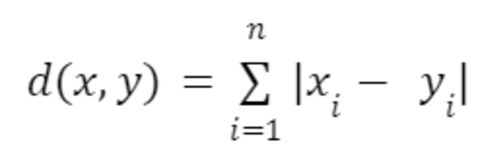

### 3. Minkowski Metric

The **Minkowski distance** is a generalization of both Euclidean and Manhattan distances. It introduces a parameter `p` that allows you to adjust the metric between L1 and L2 (or beyond).  

- If **p = 1**, it becomes the **Manhattan distance**.  
- If **p = 2**, it becomes the **Euclidean distance**.  
- Larger values of **p** give more weight to larger differences in individual features.  
- Flexible distance metric that can be tuned using the parameter **p**.  
- Sensitive to **feature scaling**, so normalization is usually recommended.  
- Commonly used in KNN, clustering, and other distance-based algorithms where a flexible distance measure is desired.


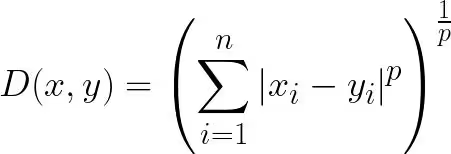

### 4. Cosine Distance

The **cosine distance** measures how different two vectors are based on the angle between them.  
It does **not** depend on the magnitudes (norms) of the vectors — only on their direction.


- Independent of vector magnitude — only the **orientation** matters.  
- Very useful when the **direction** of the vector is more important than its size.  
- Widely used in **text similarity**, e.g., comparing documents represented by word-count vectors.  
- In text tasks, scaling a document (using each word twice as often) should not change its topic —  
  cosine distance naturally handles this behavior.  
- Often used in recommendation systems, NLP, document search, embeddings, and high-dimensional data.


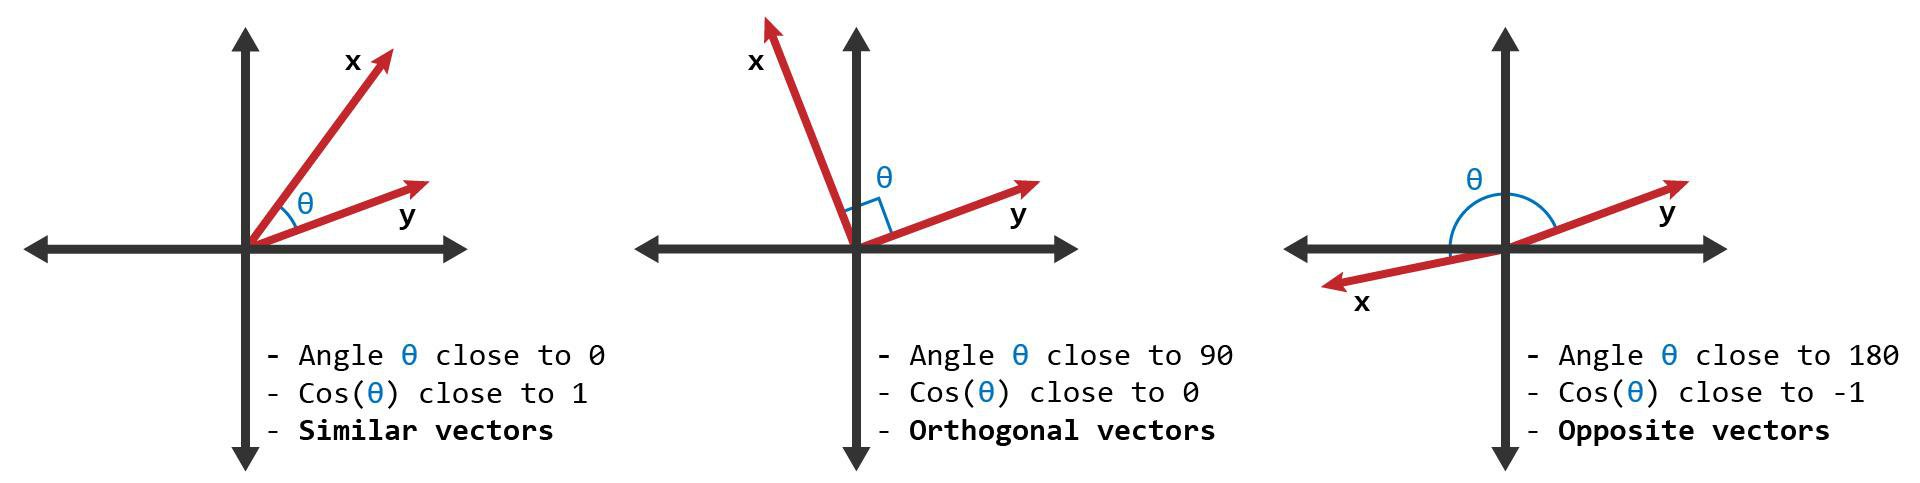

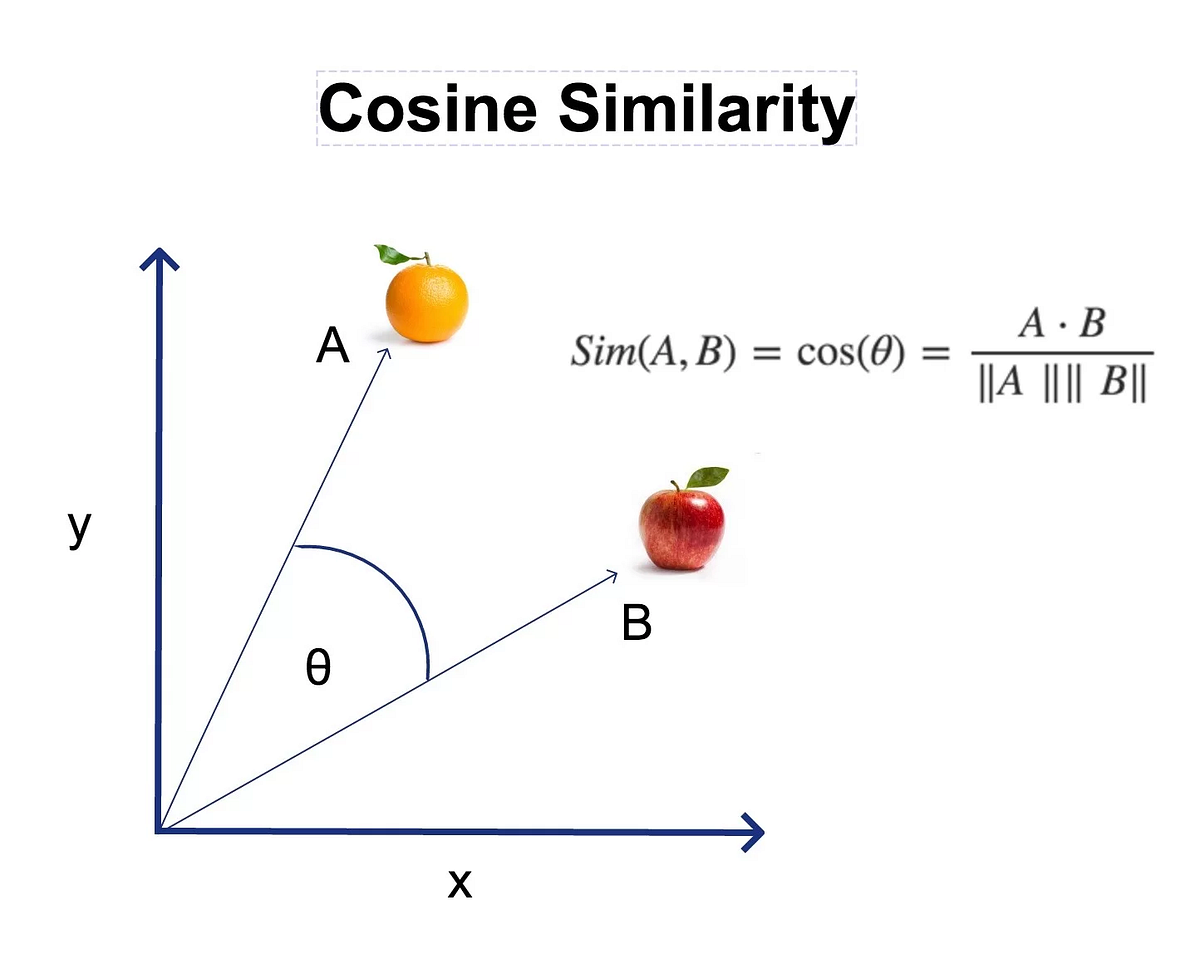

### 5. Jaccard Distance
The **Jaccard distance** measures how different two sets are.
 **When to use:**
 - When objects are **sets**, not numeric vectors.
 - Useful in:
   - text comparison (sets of words),
   - recommendation systems (viewed/liked item sets),
   - tags, keywords, categories,
   - binary features.

 **Notes:**
 - No need to convert sets into vectors.
 - In some cases may fail to satisfy the triangle inequality,
   so not always a strict metric.

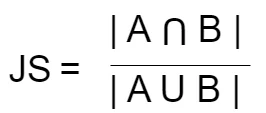

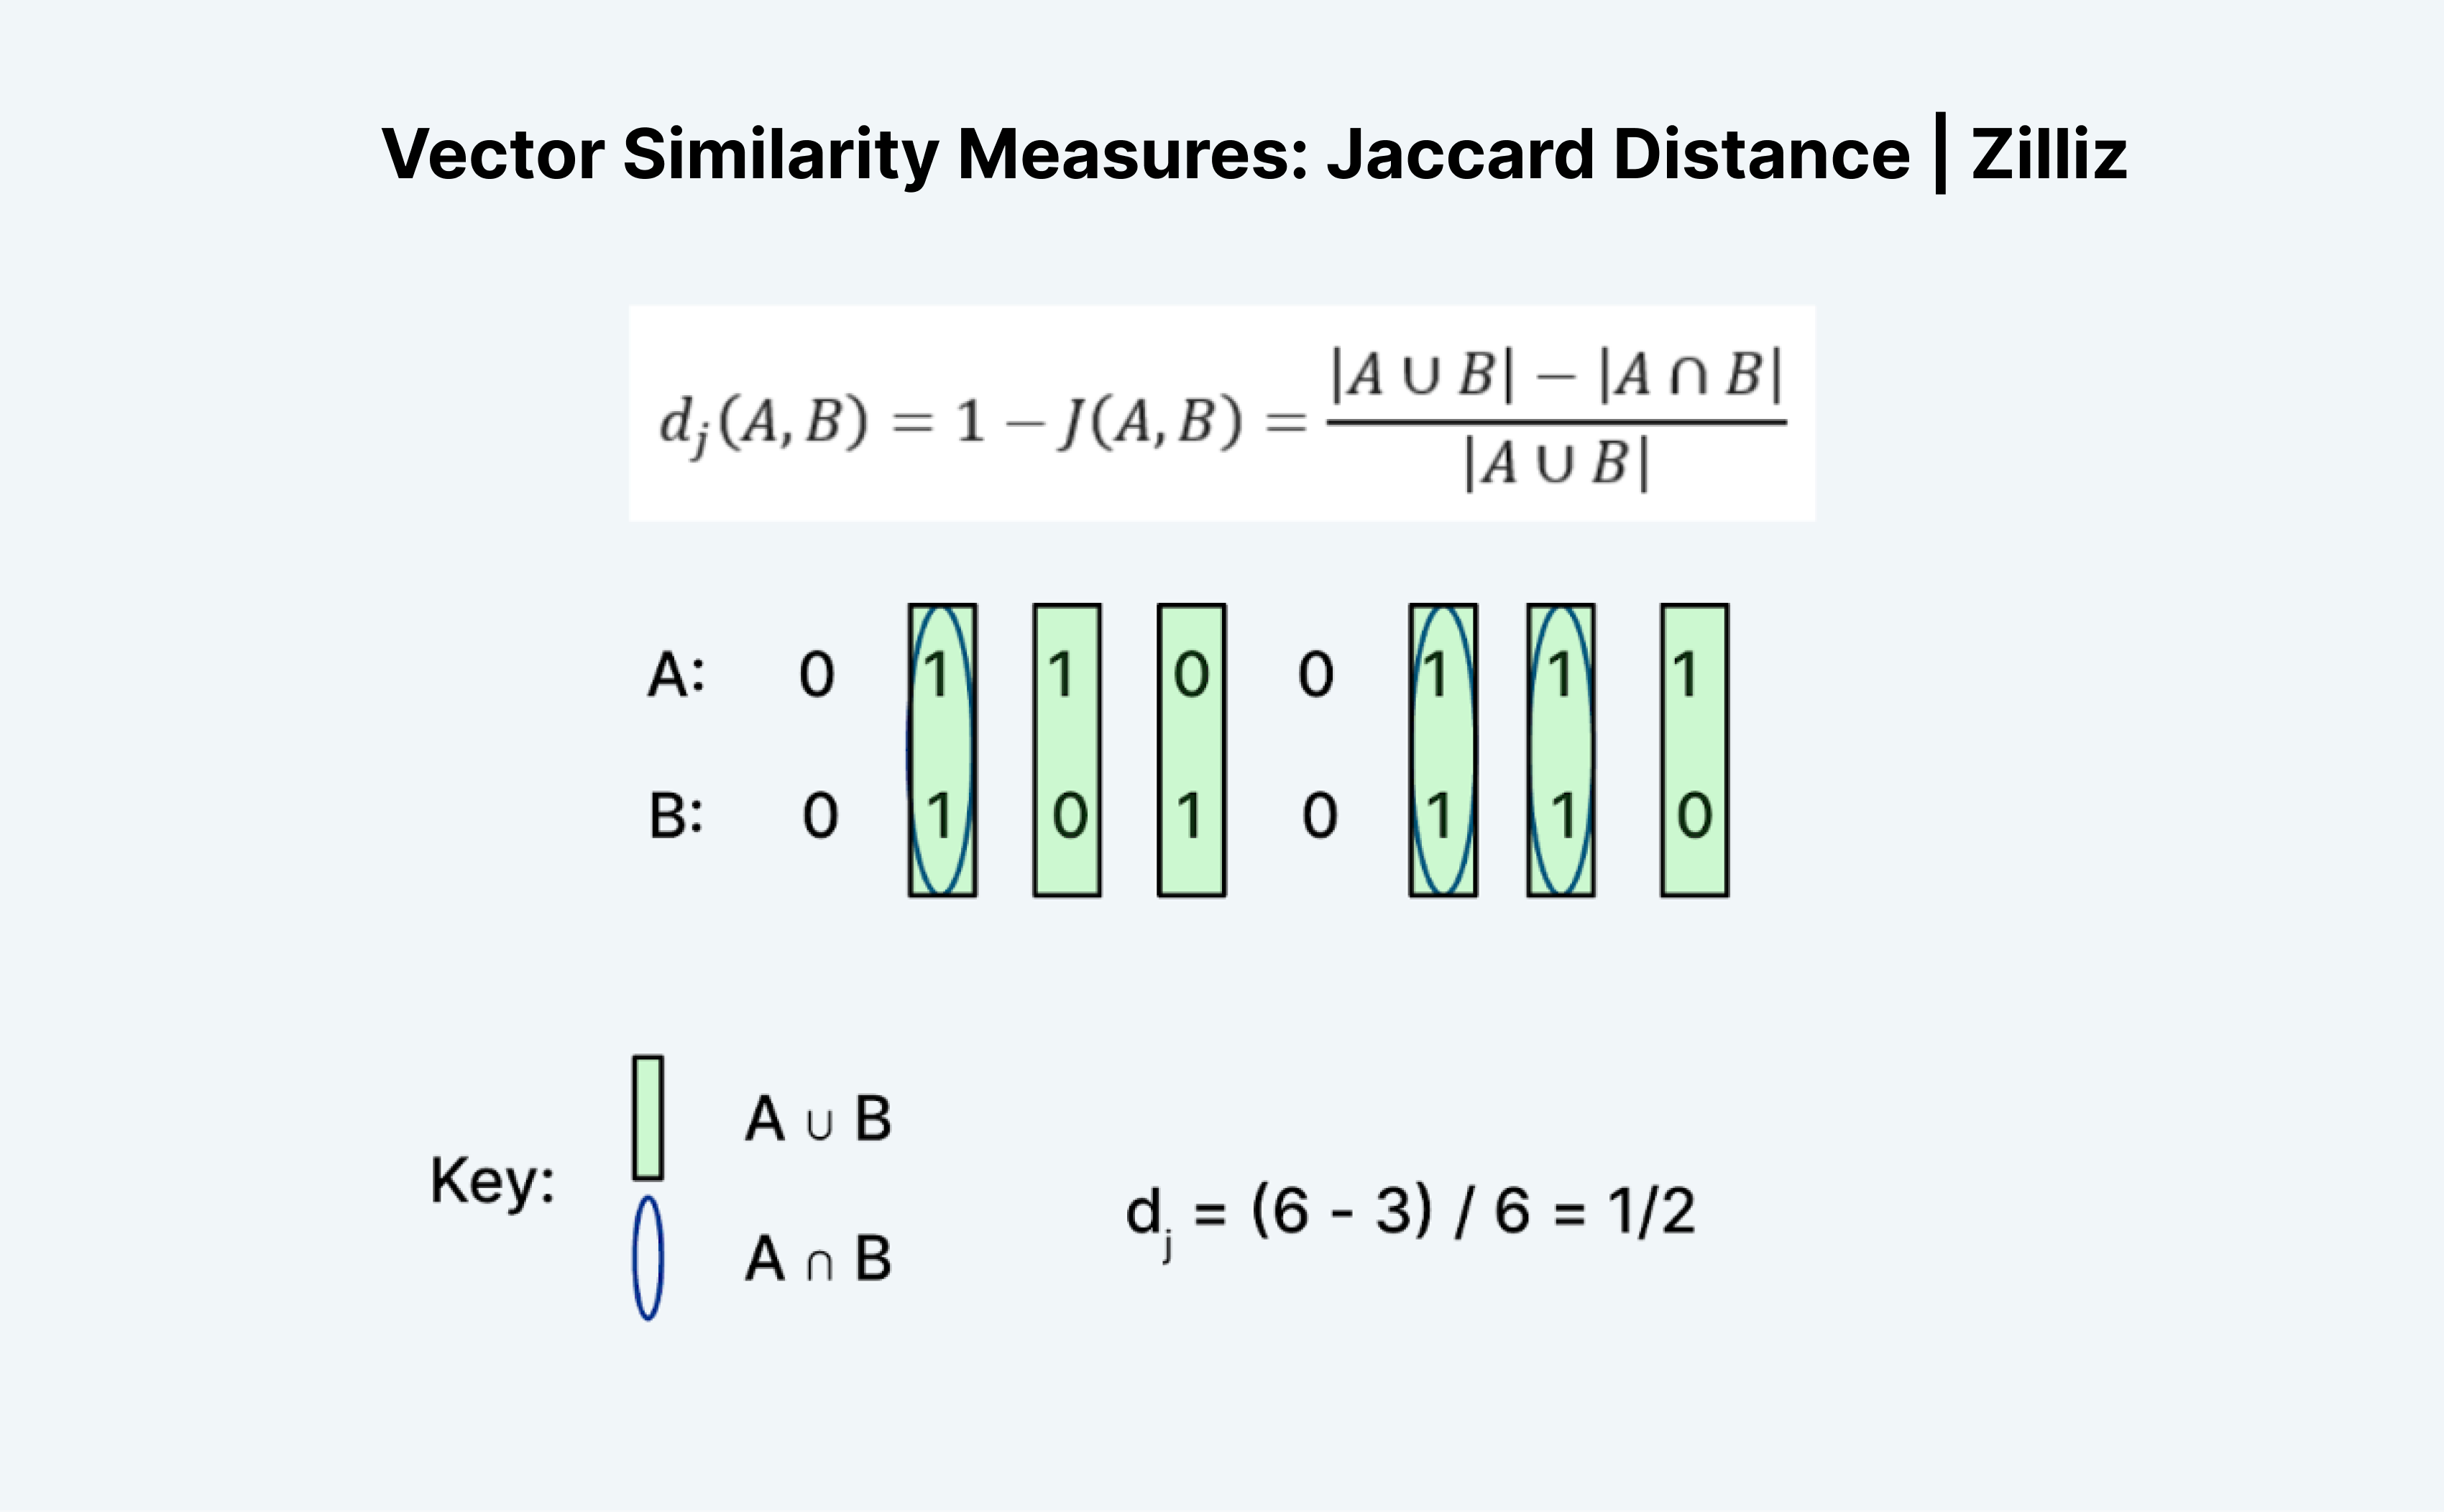

# Example 1

https://www.w3schools.com/python/python_ml_knn.asp

In [1]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

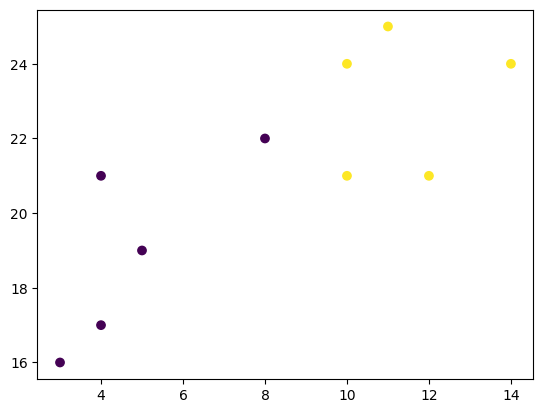

In [2]:
x = [4, 5, 10, 4, 3, 11, 14 , 8, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
classes = [0, 0, 1, 0, 0, 1, 1, 0, 1, 1]

plt.scatter(x, y, c=classes)
plt.show()

In [3]:
# Let's create and fit the knn model

features = list(zip(x, y))
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(features, classes)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


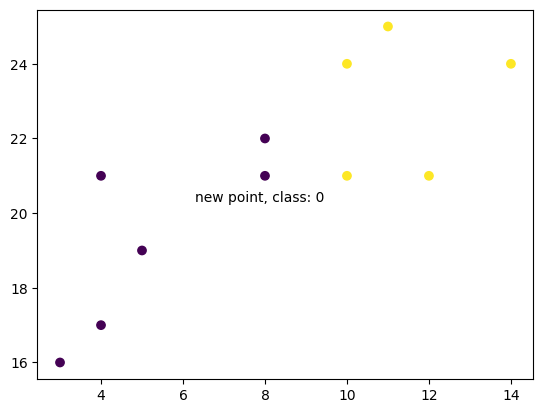

In [4]:
# Inference

test_x, test_y = 8, 21
new_point = [(test_x, test_y)]

prediction = knn.predict(new_point)

plt.scatter(x + [test_x], y + [test_y], c=classes + [prediction[0]])
plt.text(x=test_x-1.7, y=test_y-0.7, s=f"new point, class: {prediction[0]}")
plt.show()


# Example 2. Weighted KNN

### Comparison between uniform knn method and 'weighted' knn method

The basic nearest neighbors classification uses **uniform** weights: that is, the value assigned to a query point is computed from a simple majority vote of the nearest neighbors. 

Under some circumstances, it is better **to weight the neighbors** such that nearer neighbors contribute more to the fit. 

This can be accomplished through the weights keyword:
1. The default value, **weights = 'uniform'**, assigns uniform weights to each neighbor. 
2. **weights = 'distance'** assigns weights proportional to the inverse of the distance from the query point. 



### Weighted KNN
The original algorithm has one major minus: **it does not take into account the distances** to neighboring points, even though this information can be useful.

In the formula of the standard KNN, all neighbors are considered equally (with the same coefficients). If we assign weights to these neighbors, which are larger the closer the neighbor is to the target point, we get **a weighted KNN**.

https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html#sphx-glr-auto-examples-neighbors-plot-classification-py

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [6]:
iris = load_iris(as_frame=True)
X = iris.data[["sepal length (cm)", "sepal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

In [7]:
X_train

,sepal length (cm),sepal width (cm)
60,5.0,2.0
1,4.9,3.0
8,4.4,2.9
93,5.0,2.3
106,4.9,2.5
...,...,...
66,5.6,3.0
29,4.7,3.2
130,7.4,2.8
141,6.9,3.1


In [8]:
y_train

60     1
1      0
8      0
93     1
106    2
      ..
66     1
29     0
130    2
141    2
111    2
Name: target, Length: 112, dtype: int64

In [9]:
# Model pipeline

clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=11))]
)

In [10]:
#Decision boundary

#Now, we fit two classifiers with different values of the parameter weights. 
#We plot the decision boundary of each classifier as well as the original dataset to observe the difference.

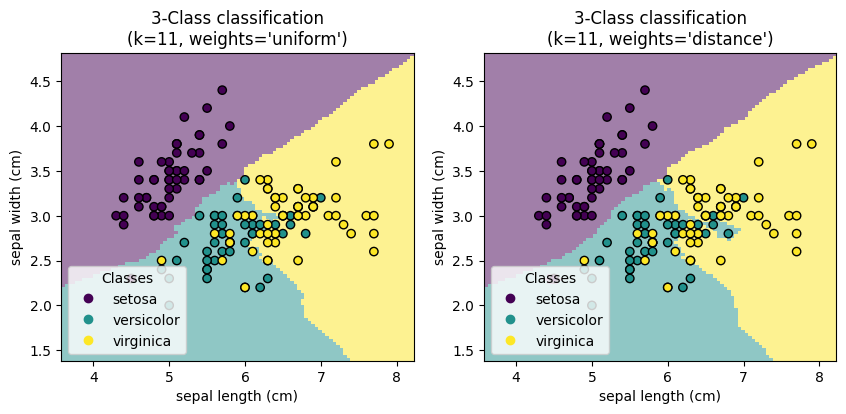

In [11]:
import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay

_, axs = plt.subplots(ncols=2, figsize=(10, 4))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()

## Conclusion
We observe that the parameter weights has an impact on the decision boundary. 

When weights="unifom" all nearest neighbors will have the same impact on the decision. Whereas when weights="distance" the weight given to each neighbor is proportional to the inverse of the distance from that neighbor to the query point.

In some cases, taking the distance into account might improve the model.

# Example 3. Regression

https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html

In [12]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import neighbors

rng = np.random.RandomState(0)
X_train = np.sort(5 * rng.rand(40, 1), axis=0)
X_test = np.linspace(0, 5, 500)[:, np.newaxis]
y = np.sin(X_train).ravel()

# Add noise to targets
y[::5] += 1 * (0.5 - np.random.rand(8))

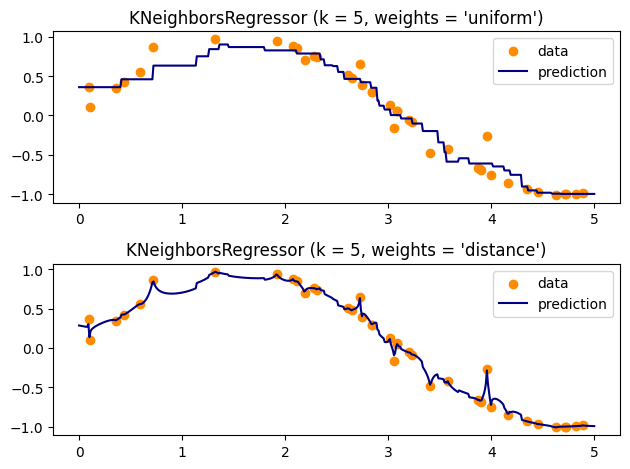

In [13]:
n_neighbors = 5

for i, weights in enumerate(["uniform", "distance"]):
    knn = neighbors.KNeighborsRegressor(n_neighbors, weights=weights)
    y_ = knn.fit(X_train, y).predict(X_test)

    plt.subplot(2, 1, i + 1)
    plt.scatter(X_train, y, color="darkorange", label="data")
    plt.plot(X_test, y_, color="navy", label="prediction")
    plt.axis("tight")
    plt.legend()
    plt.title("KNeighborsRegressor (k = %i, weights = '%s')" % (n_neighbors, weights))

plt.tight_layout()
plt.show()

# Example 4. KNN from Scratch in Python

https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/

In [14]:
import numpy as np
from collections import Counter

In [15]:
# 1. Defining the Euclidean Distance Function

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((np.array(x1) - np.array(x2)) ** 2))

In [16]:
# 2. KNN Prediction Function

def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i]) # saves how far each training point is from the test point, along with its label
        distances.append((dist, training_labels[i]))
    distances.sort(key=lambda x: x[0]) # sorting is used to sorts the list so the nearest points come first
    k_nearest_labels = [label for _, label in distances[:k]] # picks the labels of the k closest points
    return Counter(k_nearest_labels).most_common(1)[0][0] # which label appears most among those k labels that becomes the prediction

In [17]:
#3. Training Data, Labels and Test Point

training_data = [[1, 2], [2, 3], [3, 4], [6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']
test_point = [4, 5]
k = 3

In [18]:
# 4. Make a Prediction

prediction = knn_predict(training_data, training_labels, test_point, k)
print(prediction)

A


# Example 5. How to choose the value of K?

If the data has lots of noise or outliers, using a larger k can make the predictions more stable.

But if k is too large the model may become too simple and miss important patterns and this is called underfitting.

1. **Cross-Validation**: Cross-Validation is a good way to find the best value of k is by using k-fold cross-validation. 
This means dividing the dataset into k parts. The model is trained on some of these parts and tested on the remaining ones. This process is repeated for each part. The k value that gives the highest average accuracy during these tests is usually the best one to use.

2. **Elbow Method**: In Elbow Method we draw a graph showing the error rate or accuracy for different k values. As k increases the error usually drops at first. But after a certain point error stops decreasing quickly. The point where the curve changes direction and looks like an "elbow" is usually the best choice for k.

3. **Odd Values for k**: It’s a good idea to use an odd number for k especially in classification problems. This helps avoid ties when deciding which class is the most common among the neighbors.

https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

https://builtin.com/data-science/elbow-method

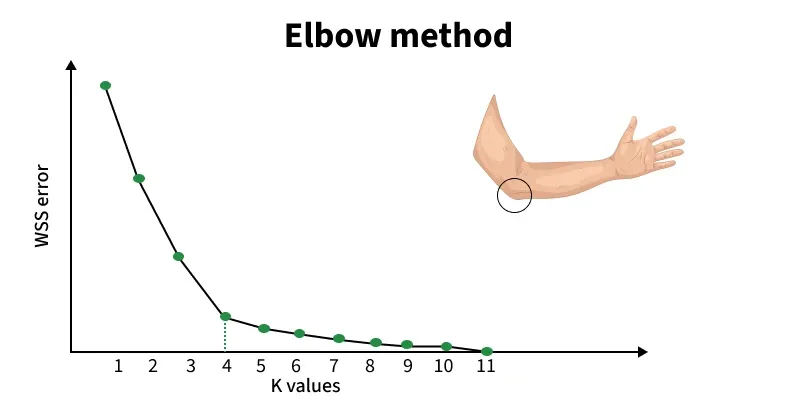

### Essence of the Elbow Method in kNN

The elbow method is a heuristic technique used to select an optimal model parameter by analyzing how model performance changes as the parameter increases.

For k-Nearest Neighbors (kNN), this parameter is k — the number of neighbors.

Steps:
1. Train a kNN model for multiple values of k
2. Measure the model error (in our case 1-accuracy) for each value of k
3. Plot k vs. error
4. Identify the point where the curve bends — the “elbow”

👉 The elbow represents the value of k beyond which increasing model complexity no longer yields significant improvement.

### Implementation of Elbow Method

In [19]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [20]:
# Go back to iris dataset

iris = load_iris(as_frame=True)
X = iris.data[["sepal length (cm)", "sepal width (cm)"]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=0
)

In [21]:
k_values = range(1, 20)
errors = []

for k in k_values:
    clf = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ]
    )
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    error = 1 - accuracy_score(y_test, y_pred)
    errors.append(error)


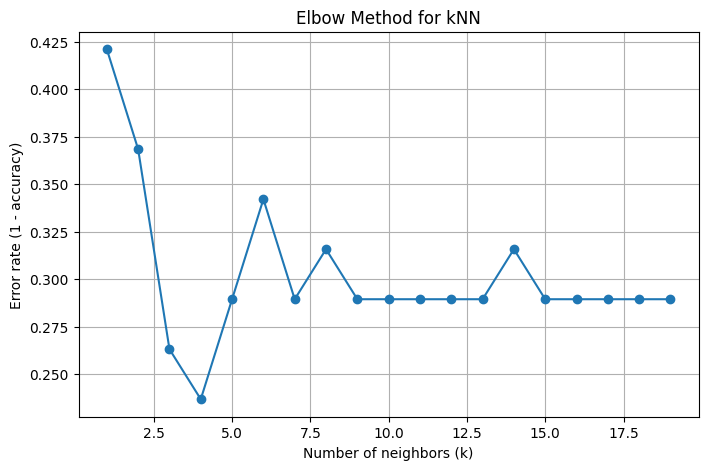

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Error rate (1 - accuracy)")
plt.title("Elbow Method for kNN")
plt.grid(True)
plt.show()

### Conclusion 

Elbow value here is k=7 because after that the error rate does not decrease significantly.